<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/2026.06/Lab4_PE_keithley_90CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photoelectric effect

v0.2.1 Automated measurements. Diodes

v0.2.2 Lamp + Filters

v0.3.0 Du Bridges method extracting V0

v0.3.1 Resume added

v0.3.2 90CV tube


# Resume

## Method

We measured photoelectric current using an [90CV](https://frank.pocnet.net/sheets/030/9/90CV.pdf) photocell connected directly
to a Keithley 2400 picoammeter, which simultaneously sourced voltage and measured
current. This wire-minimized setup avoids the distortion introduced by a
parallel voltmeter in the classical scheme.

Current–voltage (I–V) curves were recorded automatically using a
[Python script](https://github.com/evgeny-kolonsky/Lab4/blob/main/PE/photoelectric_v2.py).

As light sources we used blue 456, green 525 and yellow 592 LEDs. Their emission
spectra were measured with an Avantes spectrometer. Raw spectral data are
available on [GitHub](https://github.com/tphlabs/data/tree/main/Lab4_SP/2026.04).

The stopping voltage $V_0$ was extracted from each I–V curve using the
[Du Bridge method](https://github.com/evgeny-kolonsky/Lab4/blob/main/PE/jpsj.8.723.pdf):
plotting $\sqrt{I}$ versus $V$ and extrapolating the linear region to zero.
Measurements were repeated at several light intensities per wavelength.

## Results

The stopping voltage increases with light frequency, in qualitative agreement
with Einstein's photoelectric equation. A linear fit to $V_0(\nu)$ gives a slope
consistent with the expected value of $h/e$. Green and Yellow datapoints measured in agreement with expectations. However, the Blue light measurements return voltage lower than expected.


In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.constants import h, elementary_charge as e, speed_of_light as c

In [2]:
def wavelength_to_color(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    '''
    wavelength = float(wavelength)
    if wavelength < 380:
        wavelength = 380.
    if wavelength > 750:
        wavelength = 750.
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    r = int(R*255)
    g = int(G*255)
    b = int(B*255)
    return "#{:02x}{:02x}{:02x}".format(r, g, b)

#Volt-ampere curve


# Dark current

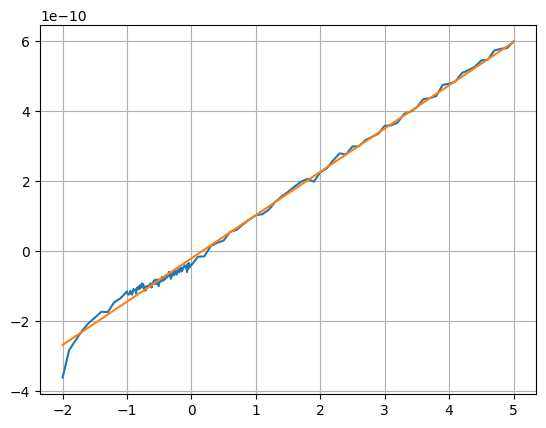

In [4]:
URL = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/2026.06/'
url = URL+'dark.csv'
LED_V,V_set,V_actual,I_avg_A, I_std_A, _, _ = np.genfromtxt(url, \
                                                    delimiter=',', skip_header=1, unpack=True)
plt.plot(V_set, I_avg_A)
#plt.yscale('symlog', linthresh=1e-10)
#plt.axhline(dark, color='lightgray')
mask = (V_set > -1)
dark = linregress(V_set[mask], I_avg_A[mask])
dark_fit = dark.slope * V_set + dark.intercept
plt.plot(V_set, dark_fit)
plt.grid()


In [9]:
# voltage where we normalizing
NORMPOINT = 0

def find_root(V, I):
  mask = (I > 0) & ( V < 0 )
  x = V[mask]
  y = np.sqrt(I[mask])
  fit = linregress(x, y)
  V0 = - fit.intercept / fit.slope
  return V0


yellow_diode_90CV_right_side 592 nm 16V -0.22V
yellow_diode_90CV_right_side 592 nm 20V -0.17V
yellow_diode_90CV_right_side 592 nm 22V -0.17V
green_diode_90CV_right_side 525 nm 12V -0.41V
green_diode_90CV_right_side 525 nm 14V -0.44V
green_diode_90CV_right_side 525 nm 18V -0.47V
green_diode_90CV_right_side 525 nm 20V -0.50V
green_diode_90CV_right_side 525 nm 22V -0.51V
blue_diode_90CV_right_side 456 nm 8V -0.49V
blue_diode_90CV_right_side 456 nm 10V -0.54V
blue_diode_90CV_right_side 456 nm 12V -0.57V
blue_diode_90CV_right_side 456 nm 14V -0.57V


/tmp/ipykernel_11356/4086784481.py:53: RuntimeWarning: invalid value encountered in sqrt
  DuBridge =   np.sqrt(Inorm[condition])


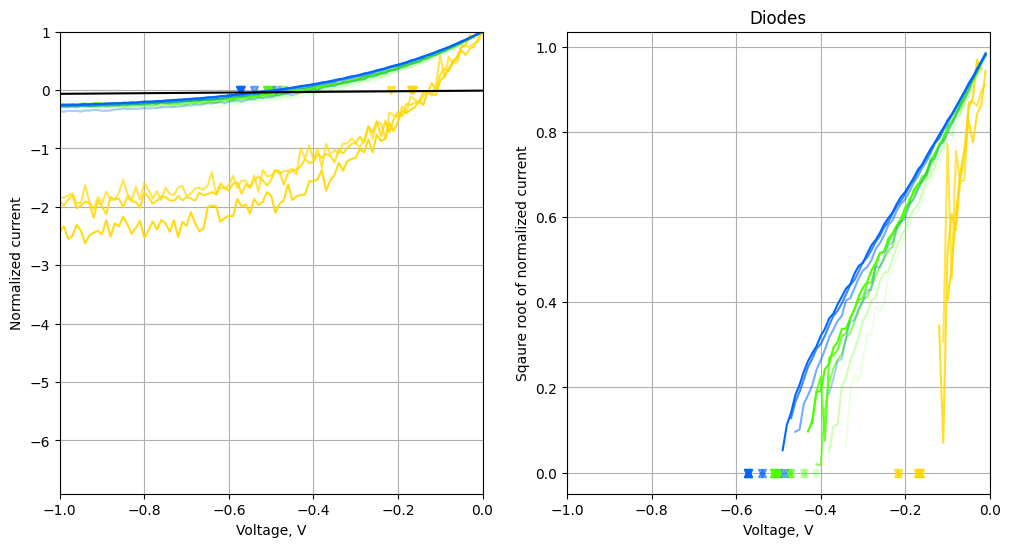

In [12]:
NORMPOINT = 0 #V
names = ['yellow_diode_90CV_right_side', 'green_diode_90CV_right_side', 'blue_diode_90CV_right_side']
waves = [592, 525, 456]
n = len(names)


fig, ax = plt.subplots(1, 2, figsize=(12,6))
plt.grid()

data = '# color wavelength power V0\n'


for i, name in enumerate(names):
  color= wavelength_to_color(waves[i])
  url = URL+ f'{name}.csv'
  #txt = requests.get(url).text
  LED_V,V_set,V_actual,I_avg_A, I_std_A, _, _ = np.genfromtxt(url, \
                                                    delimiter=',', skip_header=1, unpack=True)

  powers = np.unique(LED_V)

  for power in powers:
    if power == 6:
        continue
    if power == 24:
        continue
    if power == 0:
        continue

    mask = (LED_V == power)
    V = V_set[mask]
    I = I_avg_A[mask]
    dark_fit = dark.slope * V + dark.intercept
    I -= dark_fit
    dark_max = np.max(I)
    normalization_parameter = I[V==NORMPOINT]
    Inorm = I / normalization_parameter
    opacity = 0.1 + 0.89 * (power - np.min(powers)) / (np.max(powers) - np.min(powers))

    # Find points where current I crosses zero current line
    V0 = find_root(V, Inorm)
    ax[0].plot(V0, 0, color=color, alpha = opacity, marker='v')
    ax[1].plot(V0, 0, color=color, alpha = opacity, marker='v')
    data += f'{i} {waves[i]} {power:.0f} {-V0:.3f} # zero\n'

    plt.plot(V0, dark_max, color=color, alpha = opacity, marker='^')
    data += f'{i} {waves[i]} {power:.0f} {-V0:.3f} # right\n'

    result = f'{name} {waves[i]:.0f} nm {power:.0f}V {V0:.2f}V'
    print(result)
    ax[0].plot(V, Inorm, color=color, alpha=opacity)
    condition = Inorm < 1
    DuBridge =   np.sqrt(Inorm[condition])
    ax[1].plot(V[condition], DuBridge, color=color, alpha=opacity, label=f'{name} {power:.0f}V {V0:.2f}V')


ax[0].plot(V, dark_fit / normalization_parameter, \
                 color='black', label='dark current')
#ax[0].legend()
ax[0].set_xlim(-1, 0)
ax[0].set_ylim(top=1)
ax[0].grid()
ax[1].set_xlim(-1, 0)

ax[0].set_xlabel('Voltage, V')
ax[0].set_ylabel('Normalized current')
ax[1].set_xlabel('Voltage, V')
ax[1].set_ylabel(r'Sqaure root of normalized current')
plt.title('Diodes')
plt.show()


# Plank's constant and Work potential determination

$$
 e V_0(\nu) = h \nu -  e W
$$

/tmp/ipykernel_11356/9855336.py:7: RuntimeWarning: divide by zero encountered in divide
  return c / wl


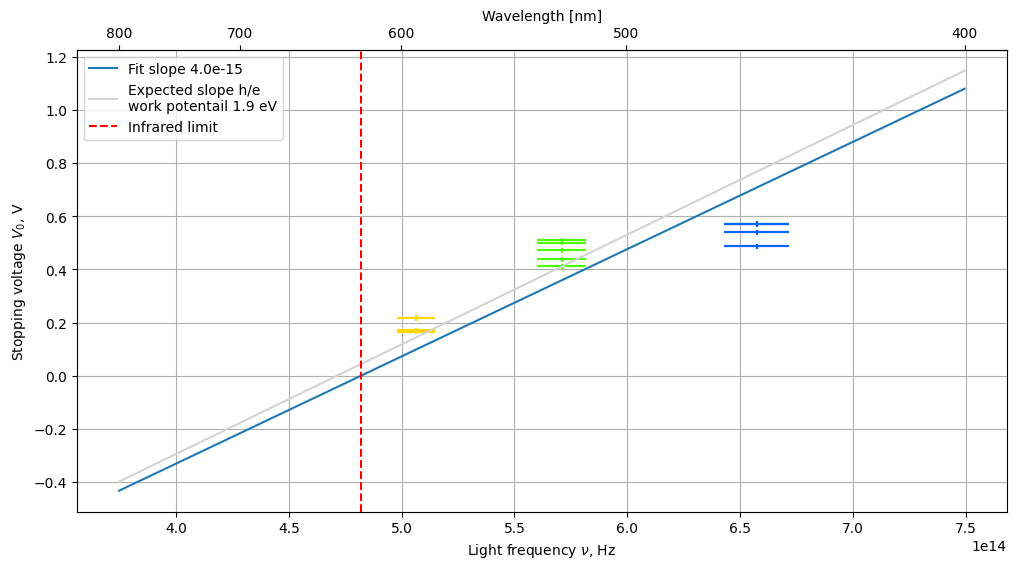

In [11]:
offset_expected = 1.95 # V, for Cs-Sb Photocathode

def linear(nu, slope):
    return slope * nu - offset_expected

def wl2freq(wl):
    return c / wl


def freq2wl(nu):
    return c / nu * 1e9

fig, ax = plt.subplots(figsize=(12,6))


secax = ax.secondary_xaxis('top', functions=(freq2wl, wl2freq))
secax.set_xlabel('Wavelength [nm]')


ix, wl, power, V0 = np.genfromtxt(data.splitlines()).T


relative_error = 10 / wl # error 10 nm

wl *= 1e-9
nu = c / wl
energy = h * nu / e # eV
nu_err = nu * relative_error
energy_err = energy * relative_error
V_err = 0.01 # V
# curve fit takes into account weights of uncertainties
# so it is more accurate than linregress calculates slope and offset
popt, pcov = curve_fit(linear, nu , V0)
slope = popt[0]
#offset = popt[1]
err = np.sqrt(np.diag(pcov))
slope_err = err[0]
#offset_err = err[1]

# errors in coeffs of linear regression, as in Taylor Ch8.
#y = V0
#x = nu
#N = len(y)
#sigma2_y = np.sum( (y - offset_expected - slope * x)**2) / (N - 2)
#Delta = N * np.sum(x**2) - np.sum(x)**2
#offset_err = np.sqrt(sigma2_y * np.sum(x**2) / Delta)
#slope_err = np.sqrt(N * sigma2_y / Delta)

for i in range(len(V0)):
  ind = int(ix[i])
  plt.errorbar(nu[i], V0[i], yerr=V_err, xerr=nu_err[i], ls='', color=wavelength_to_color(wl[i]*1e9))

wl_dense = np.linspace(400, 800)  * 1e-9
nu_dense = c / wl_dense

plt.plot(nu_dense, linear(nu_dense, slope), label=f'Fit slope {slope:.1e}')
plt.plot(nu_dense, linear(nu_dense, h/e) , color='lightgray', label=f'Expected slope h/e\nwork potentail {offset_expected:.1f} eV')

#for i in range(len(V0)):
#    plt.annotate(f'{wl[i]*1e9:.0f} nm', (V0[i], energy[i]))

plt.grid()
plt.legend()
plt.xlabel(r'Light frequency $\nu$, Hz')
plt.ylabel(r'Stopping voltage $V_0$, V')
Infrared_PhotoEmission_limit = offset_expected / slope
plt.axvline(Infrared_PhotoEmission_limit, color='red', ls='--', label='Infrared limit')
plt.legend()
plt.show()
#plt.xlim(0.2, 1)
plt.show()

